In [1]:
import xgi
import numpy as np
from tqdm import tqdm
import pickle
from random import shuffle
from multiprocess import Pool
from had_model import HAD_model
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from hypergraph_models import stratified_er_hypergraph

# Generate a bimodal distribution

in the interval [0,1], as the sum of two normal distributions.

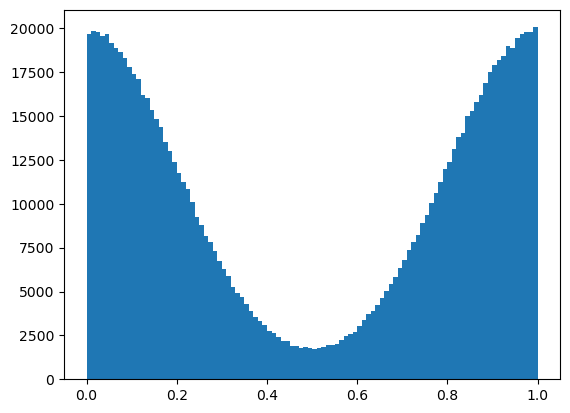

In [3]:
# parameters for bimodal distribution of initial opinions
means = [0.,1.]
std = 0.2

# plot the distribution
n_samp = 1000000
samp1 = np.random.normal(means[0], std, n_samp)
samp2 = np.random.normal(means[1], std, n_samp)
samp = [i for i in np.hstack((samp1,samp2)) if i>0. and i<1.]
plt.hist(samp, bins=100)
plt.show()

# Run the model with initial opinions drawn from bimodal distributon

In [6]:
# auxiliary functions to parallelize computations
def get_results(args):

    N, ks_avg, eps, cond = args
    #H = xgi.uniform_erdos_renyi_hypergraph(N, M, k_avg, p_type="degree")
    H = stratified_er_hypergraph(N, ks_avg, p_type='degree')
    H.cleanup()
    groups_0 = H.edges.members()

    # draw initial opinions from bimodal distribution
    n_samp = N*2
    samp1 = np.random.normal(means[0], std, n_samp)
    samp2 = np.random.normal(means[1], std, n_samp)
    samp = [i for i in np.hstack((samp1,samp2)) if i>0. and i<1.]
    shuffle(samp)
    opinions_0 = samp[:N]
    
    Model = HAD_model(eps, groups_0, opinions_0)
    results = Model.simulate(condition=cond)
    opinions = results['opinions']
    groups = results['groups']

    return (groups, opinions, len(groups_0))

In [8]:
epsilons = np.linspace(0., 0.6, num=25)[1:]
Ns = [500, 1000, 2000, 5000]
ks_avg = [3, -1, 3, -1, 3] 
# condition for agreement
cond = 'max_min'
# number of iterations for each epsilon
iterations = 20
# number of processes for parallelization
n_process = 8


ncc = dict()
scc1 = dict()
scc2 = dict()
nhe = dict()
s_avg = dict()
s_max = dict()

for N in Ns:
    
    # All below quantities are computed at the steady state, as a function of epsilon, averaged over 'iterations'
    ncc[N] = []      # number of connected components
    scc1[N] = []     # size of the largest connected component
    scc2[N] = []     # size of the second largest connected component
    nhe[N] = []      # number of hyperedges
    s_avg[N] = []    # average hyperedge size
    s_max[N] = []    # max hyperedge size
                  
    for eps in tqdm(epsilons):

        p = Pool(processes=n_process)
        args = [(N, ks_avg, eps, cond)] * iterations
        res_runs = p.map(get_results, args)

        ncc_it = []
        scc1_it, scc2_it = [], []
        nhe_it = []
        s_avg_it, s_max_it = [], []
        
        for res in res_runs:     
            
            groups, opinions, ng_0 = res[0], res[1], res[2]
            # number of connected components and size of the two largest
            hedges = groups[-1]
            h = xgi.Hypergraph(hedges)
            # list of connected components
            cc = [j for j in xgi.connected_components(h)]
            ncc_it.append( len(cc) )                    
            scc = set([len(i) for i in cc])
            scc1_it.append( max(scc) / N )
            scc.remove(max(scc))
            if scc:
                scc2_it.append( max(scc) / N )
            else:
                scc2_it.append(0)
    
            # relative number of hyperedges
            nhe_it.append( len(groups[-1]) / ng_0 )
            
            # relative avg and std of hyperedge sizes
            sizes_end_it = [len(e) for e in groups[-1]]
            s_avg_it.append( np.mean(sizes_end_it) )
            s_max_it.append( np.max(sizes_end_it) )
            
        ncc[N].append(np.mean(ncc_it))
        scc1[N].append(np.mean(scc1_it))
        scc2[N].append(np.mean(scc2_it))
        nhe[N].append(np.mean(nhe_it))
        s_avg[N].append(np.mean(s_avg_it))
        s_max[N].append(np.mean(s_max_it))

results = {
    'epsilons': epsilons,
    'ncc': ncc,
    'scc1': scc1,
    'scc2': scc2,
    'nhe': nhe,
    's_avg': s_avg,
    's_max': s_max
    }


s_str = ''
it = 0
while it < len(ks_avg):
    if ks_avg[it]>0:
        s_str += f'{it+2}'
    it +=1
    
# save results
with open(f'../results/ER_s{s_str}_{cond}_bimodal_{means[0]}_{means[1]}.pkl', 'wb') as fp:
        pickle.dump(results, fp)

100%|████████████████████████████████████████| 24/24 [4:51:03<00:00, 727.66s/it]


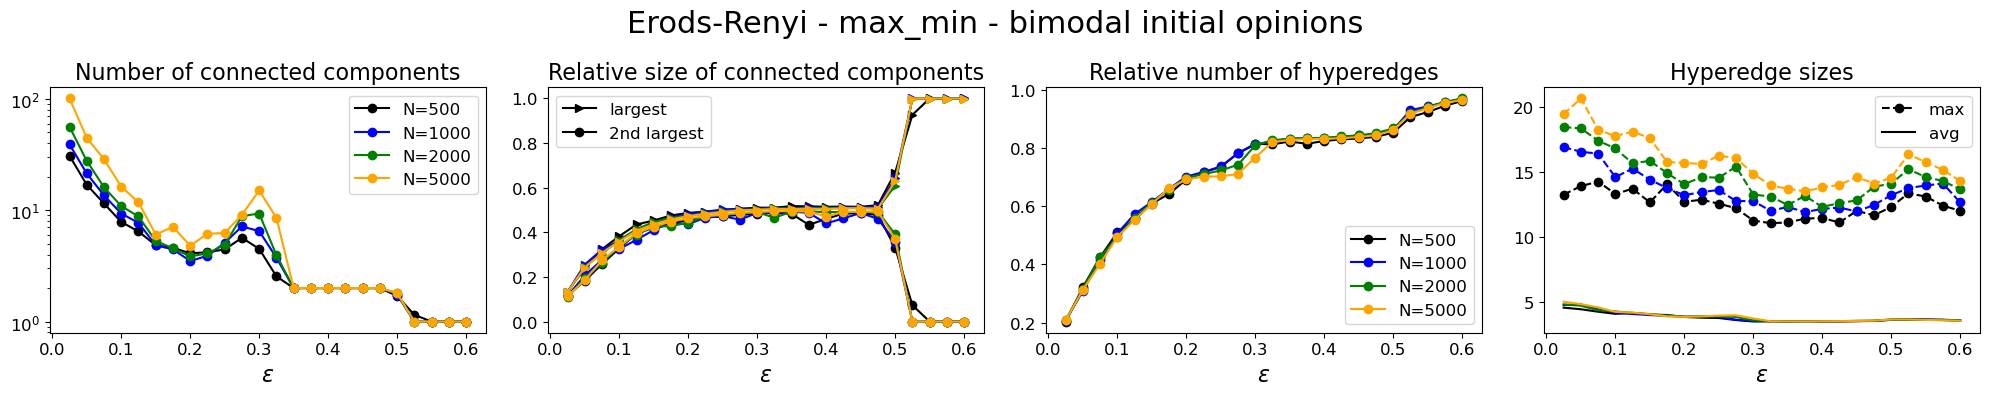

In [11]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
means = '0.0_1.0'

ncol = 4
fig, axs = plt.subplots(1, ncol, figsize=(20, 4))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N


with open(f'../results/ER_s246_{cond}_bimodal_{means}.pkl', 'rb') as f:
    results = pickle.load(f)
    
epsilons = results['epsilons']
ncc = results['ncc']
scc1 = results['scc1']
scc2 = results['scc2']
nhe = results['nhe']
s_avg = results['s_avg']
s_max = results['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
for N,clr in zip(Ns, colors):
                               
    y0 = ncc[N]
    y1 = scc1[N]
    y2 = scc2[N]
    y3 = nhe[N]
    y4 = s_avg[N]
    y5 = s_max[N]
    
    axs[0].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
    axs[0].set_yscale('log')
    axs[0].legend(fontsize=lgd_size)
    axs[0].set_title('Number of connected components', fontsize=ttl_size)

    la0 = lbls[0] if N==Ns[0] else None
    la1 = lbls[1] if N==Ns[0] else None
    axs[1].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=la0)
    axs[1].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=la1)
    axs[1].legend(fontsize=lgd_size)
    axs[1].set_title('Relative size of connected components', fontsize=ttl_size)
    
    axs[2].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')
    axs[2].legend(fontsize=lgd_size)
    axs[2].set_title('Relative number of hyperedges', fontsize=ttl_size)

    la2 = lbls[2] if N==Ns[0] else None
    la3 = lbls[3] if N==Ns[0] else None
    axs[3].plot(epsilons, y5, label=la3, linestyle='--', marker='o', color=clr)
    axs[3].plot(epsilons, y4, label=la2, color=clr)
    axs[3].legend(fontsize=lgd_size)
    axs[3].set_title('Hyperedge sizes', fontsize=ttl_size)

    # set tick fontsize in all subplots
    for j in range(4):
        axs[j].tick_params(labelsize=12)

for j in range(ncol):
    axs[j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    
plt.suptitle(f'Erods-Renyi - {cond} - bimodal initial opinions', fontsize=int(ttl_size*1.4))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_bimodal_{means}.jpg')
plt.show()

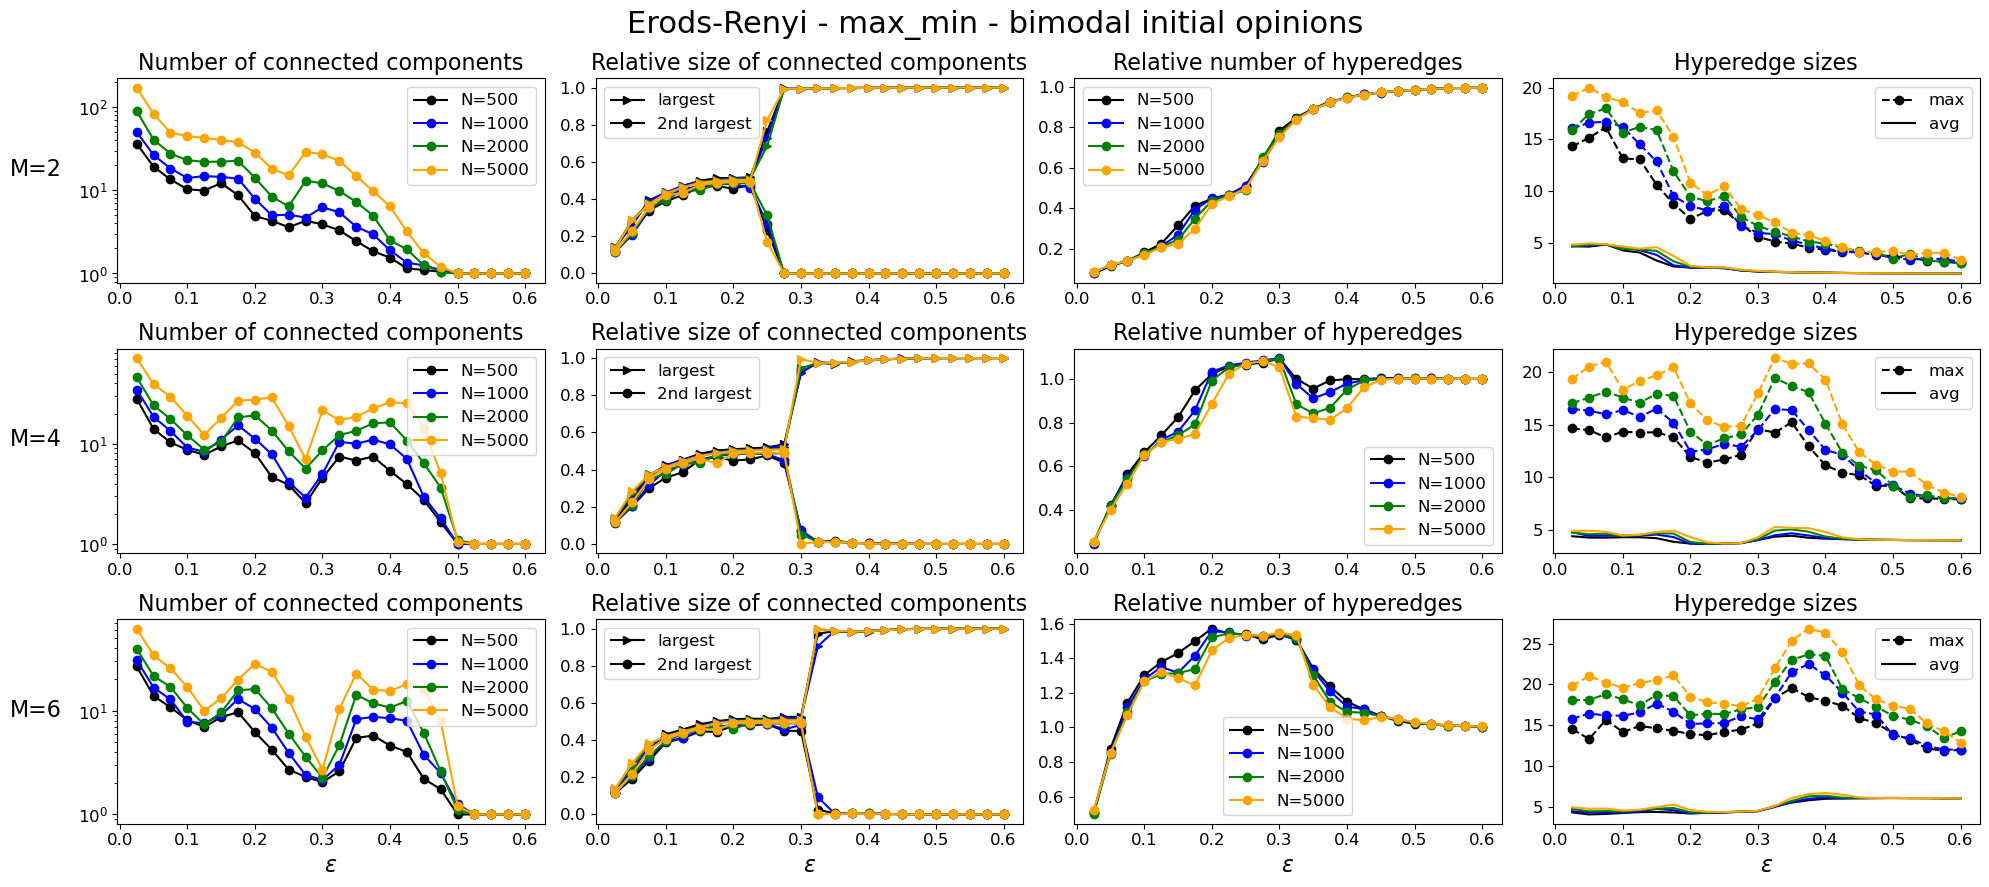

In [5]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

ncol = 4
fig, axs = plt.subplots(len(Ms), ncol, figsize=(20, 3*len(Ms)))
ttl_size = 16
lgd_size = 12
colors = ['black', 'blue', 'green', 'orange']  # one color for each value of N

for M in Ms:

    with open(f'../results/ER_M{M}_{cond}_bimodal_0.3_0.7.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']

    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        i = Ms.index(M)
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[i,0].plot(epsilons, y0, color=clr, marker='o', label=f'N={N}')
        #axs[i,0].set_xscale('log')
        axs[i,0].set_yscale('log')
        axs[i,0].legend(fontsize=lgd_size)
        axs[i,0].set_title('Number of connected components', fontsize=ttl_size)

        la0 = lbls[0] if N==Ns[0] else None
        la1 = lbls[1] if N==Ns[0] else None
        axs[i,1].plot(epsilons, y1, color=clr, linestyle='-', marker='>', label=la0)
        axs[i,1].plot(epsilons, y2, color=clr, linestyle='-', marker='o', label=la1)
        axs[i,1].legend(fontsize=lgd_size)
        axs[i,1].set_title('Relative size of connected components', fontsize=ttl_size)
        
        axs[i,2].plot(epsilons, y3, color=clr, marker='o', label=f'N={N}')
        axs[i,2].legend(fontsize=lgd_size)
        axs[i,2].set_title('Relative number of hyperedges', fontsize=ttl_size)

        la2 = lbls[2] if N==Ns[0] else None
        la3 = lbls[3] if N==Ns[0] else None
        axs[i,3].plot(epsilons, y5, label=la3, linestyle='--', marker='o', color=clr)
        axs[i,3].plot(epsilons, y4, label=la2, color=clr)
        axs[i,3].legend(fontsize=lgd_size)
        axs[i,3].set_title('Hyperedge sizes', fontsize=ttl_size)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[i,j].tick_params(labelsize=12)
        #lbls = [None for jj in lbls]

    axs[i,0].set_ylabel(f'M={M}', rotation=0, fontsize=ttl_size, labelpad=30)

for j in range(ncol):
    axs[len(Ms)-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    
plt.suptitle(f'Erods-Renyi - {cond} - bimodal initial opinions', fontsize=int(ttl_size*1.4))

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_bimodal_0.3_0.7.jpg')
plt.show()